# House Price GPT 
*Week 2 Practice of LLM Engineering course*

Outline:
1. Non-AI layer: Define the data (.db) and functions (for tool call) 
2. AI layer: Define system prompt and AI model with multimodal and streaming capability
3. Interface layer: Gradio and model switching capability

### Part 1: Defining the backend layer (Non-AI)



*Import libraries*

In [27]:
import os
import json
import requests
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display
import sqlite3
import gradio as gr
import base64
from io import BytesIO
from PIL import Image

*Define data and functions*

In [36]:
#Define data

average_rent = {
    "Kensington": 3800, "Chelsea": 3600, "South Kensington": 3400,
    "Fulham": 2500, "Hammersmith": 2300, "Earl's Court": 2700,
    "Putney": 2100, "Clapham": 2000, "Battersea": 2200,
    "Wimbledon": 1900, "Richmond": 2300, "Chiswick": 2400,
    "Ealing": 1800, "Shepherd's Bush": 2100, "Acton": 1700,
    "Paddington": 2900, "Marylebone": 3500, "Canary Wharf": 2700,
    "Greenwich": 1800, "Stratford": 1900, "Lewisham": 1600,
    "Croydon": 1400, "Barking": 1300, "Ilford": 1350,
    "Wembley": 1700
}

# Define DB
DB = "LondonRentPrice.db"

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute('CREATE TABLE IF NOT EXISTS LondonRentPrice (area TEXT PRIMARY KEY, price REAL)')
    conn.commit()

def set_rent_price(area, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO LondonRentPrice (area, price) VALUES (?,?) ON CONFLICT(area) DO UPDATE SET price = ?', (area.lower(), price, price))
        conn.commit()

for area, price in average_rent.items():
    set_rent_price(area, price)

# Define function & tools

def get_rent_price(area):
    print(f"DATABASE TOOL CALLED: Getting price for {area}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM LondonRentPrice WHERE area = ?', (area.lower(),))
        result = cursor.fetchone()
        return f"Rent price in {area} is £{result[0]}" if result else "No price data available for this area"

price_function = {
    "name": "get_rent_price",
    "description": "Get the rent price of a house in the specified area.",
    "parameters": {
        "type": "object",
        "properties": {
            "rent_area":{
                "type": "string",
                "description": "The area that the user wants to rent in"
            }
        },
     },
    "required": ["rent_area"],
    "additionalProperties": False
}

tools = [{"type": "function", "function": price_function}]

In [22]:
# Testing the function
get_rent_price("Wembley")

DATABASE TOOL CALLED: Getting price for Wembley


'Rent price in Wembley is £1700.0'

### Part 2: Defining the AI layer

*Define model and API key*

In [23]:
load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print (f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

MODEL_GPT = "gpt-4.1-nano"
openai = OpenAI()

OpenAI API Key exists and begins sk-proj-


*Define chat and multi-modal function*
1. Multi-modal AI assistant with image and audio generation
2. Tool calling with database lookup
3. Wrapped into chat model AI that collects the conversation history

Text to sound and image creation modelling

In [32]:
# Defining the text to sound function
def talker(message):
    response = openai.audio.speech.create(
        model = "gpt-4o-mini-tts",
        voice = "onyx", #Options: onyx, alloy, coral
        input = message
    )
    return response.content

# Defining the image creation function
def maps(area):
    image_response = openai.images.generate(
            model="gpt-image-1-mini",
            prompt=f"""
            Generate a clean vector-style London map centered on the {area} area. 
            Highlight the area with a red pin and label. 
            Show nearby areas, major roads, rivers, parks, and landmarks. 
            Use a modern Google Maps-inspired style with accurate geography and readable labels. 
            Suitable for a housing search application.""",
            size="1024x1024",
            n=1
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

Tool caller and chat wrapper model

In [50]:
# Defining the system prompt
system_message = """
You are a London housing price assistant.
For any question about housing prices, rents, or areas, use the housing database tool.
Rules:
- Never make up prices.
- If the area is unclear, ask for clarification.
- Use tool results as the source of truth.
- Display prices in GBP.
- If no data is found, say so clearly.
Keep responses concise.
"""

# Defining the call tool function; later will be referred in chat(history)

def handle_tool_calls_and_return_cities(message):
    responses = []
    areas = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_rent_price":
            arguments = json.loads(tool_call.function.arguments)
            area = arguments.get('rent_area')
            areas.append(area)
            price_details = get_rent_price(area)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, areas

# Defining the chat function - lightweight (text only), fullmodal, fullmodal with streaming
def chat_textonly(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(
        model = MODEL_GPT,
        messages = messages,
        tools = tools
    )

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, areas = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(
            model = MODEL_GPT,
            messages = messages,
            tools = tools
        )
    return response.choices[0].message.content

def chat_fullmodal(history):
    history = [{"role": h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(
        model=MODEL_GPT,
        messages = messages,
        tools = tools)
    areas = []
    image = None

    while response.choices[0].finish_reason =="tool_calls":
        message = response.choices[0].message
        responses, areas = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(
            model = MODEL_GPT,
            messages = messages,
            tools = tools
        )
    
    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if areas:
        image = maps(areas[0])

    return history, voice, image

*Test the models*

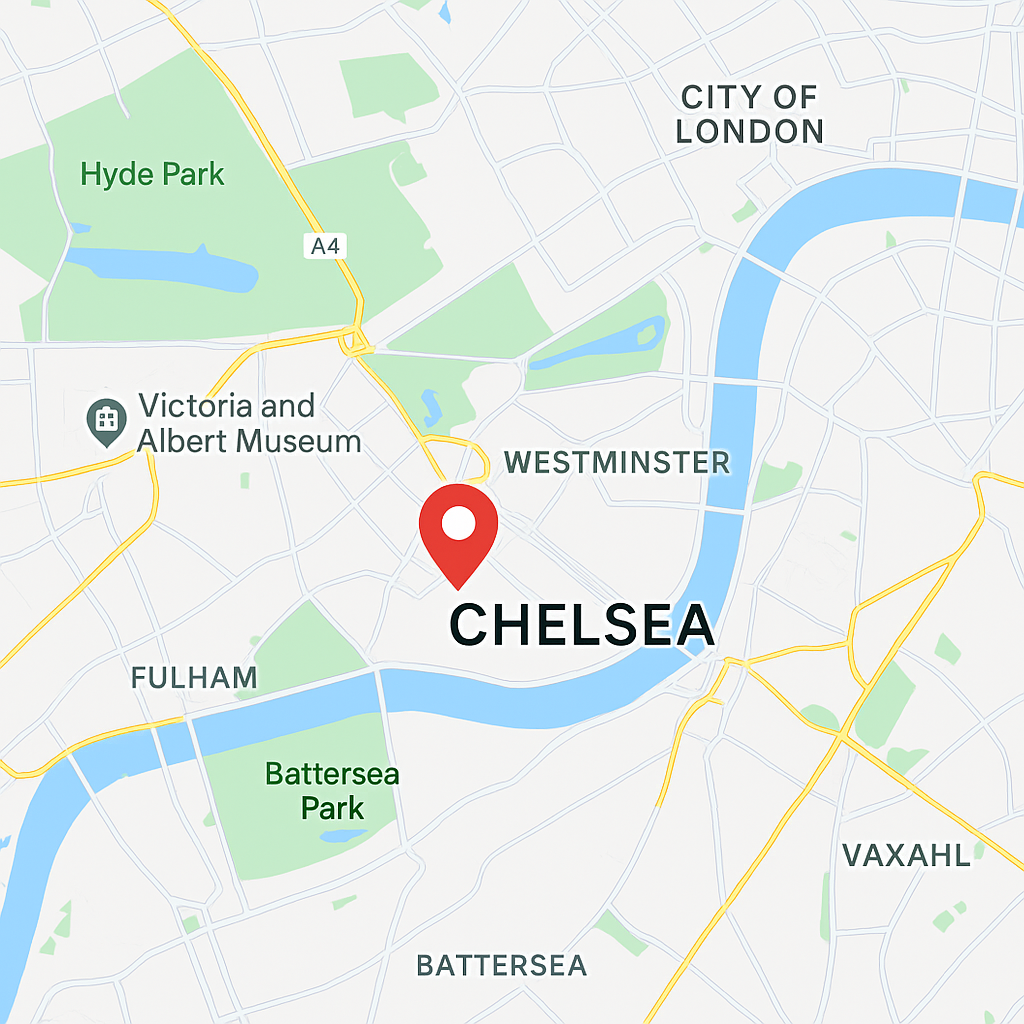

In [ ]:
#Text only
#gr.ChatInterface(fn=chat_textonly, type="messages").launch()

#Image
# map = maps("Chelsea")
# display(map)

### Part 3: Gradio Interface definition

*Using gr.Blocks to pile together the image, audio, and chatbox*

In [ ]:
# Callbaacks (along with the chat() function defined earlier)

def put_message_in_chatbot(message, history):
    return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(
        put_message_in_chatbot,
        inputs=[message,chatbot],
        outputs=[message,chatbot]).then(
            chat_fullmodal, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
        )

ui.launch(inbrowser=True, share=True)

* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://1254a21ff46d274594.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


DATABASE TOOL CALLED: Getting price for Acton
DATABASE TOOL CALLED: Getting price for Shepherd's Bush


### Future Works: with streaming

In [ ]:
#with streaming version
def chat_fullmodal_withstreaming(history):
    history = [{"role": h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    areas = []
    image = None

    while True:
            stream = openai.chat.completions.create(
                model=MODEL_GPT,
                messages = messages,
                tools = tools,
                stream = True)
            
            response = ""
            finish_reason = None
            tool_calls = {}

            for chunk in stream:
                choice = chunk.choices[0]
                if choice.finish_reason:
                    finish_reason = choice.finish_reason
                delta = choice.delta

                #normal answer
                if delta.content:
                    response += delta.content
                
                #tool call
                if delta.tool_calls:
                    for tc in delta.tool_calls:
                        idx = tc.index
                        if idx not in tool_calls:
                            tool_calls[idx] = {
                                "id":"",
                                "name":"",
                                "arguments":""
                            }
                
                        if tc.id:
                            tool_calls[idx]["id"]: tc.id
                        
                        if tc.function:
                            if tc.function.name
                response += chunk.choices[0].delta.content or ''
                yield response
    
    while response.choices[0].finish_reason =="tool_calls":
        message = response.choices[0].message
        responses, areas = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(
            model = MODEL_GPT,
            messages = messages,
            tools = tools
        )
    
    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if areas:
        image = maps(areas[0])

    return history, voice, image